# 1. Project Overview

The general goal of this project is to build a machine learning model that predicts customer churn.

Customer churn is an important business problem because losing existing customers can be more expensive than retaining them. A reliable churn prediction model can help identify customers who are at risk of leaving and support targeted retention strategies.

The project covers the complete machine learning workflow, including:
- data loading and exploration,
- data cleaning and preprocessing,
- handling class imbalance,
- train/test splitting,
- cross-validation,
- model comparison,
- hyperparameter optimization,
- classification threshold optimization,
- final model evaluation and error analysis.

The target variable is `churned`, where:
- `0` represents a customer who did not churn,
- `1` represents a customer who churned.

The main goal is to identify as many potential churners as possible while maintaining reasonable prediction quality. For this reason recall and the F2 score are treated as important evaluation metrics.

# 2. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_predict, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    RocCurveDisplay,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import os

# 3. Load Data and Duplicates

The dataset contains 10,000 observations describing customer demographics, behaviour, account characteristics and churn status. 30 customer IDs appear more than once, resulting in 60 observations. The repeated IDs are not exact duplicate rows and contain different customer attributes. Because these repeated IDs are assumed to result from a technical data-quality issue, each row is treated as an independent observation and `customer_id` is excluded from the feature set.

For the purpose of this project, it is assumed that duplicate customer_id results from a system error. Given the drastic differences in demographic features across these duplicate records, each instance is treated as representing a distinct customer. For this reason, the duplicated customer records were retained. Removing them automatically could result in the loss of potentially valuable information and reduce the amount of data available for model training.

In [2]:
data = pd.read_csv("../data/subscription_customers_dirty.csv")

data.head()

,customer_id,age,city,plan,acquisition_channel,join_date,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
0,C000001,32,Poznań,Basic,referral,2022-05-21,7500.94,37,15,1,9.0,1,5,149.74,0
1,C000002,38,Łódź,Standard,paid_search,2024-11-26,5549.57,7,0,0,6.0,1,0,94.50,0
2,C000003,39,Warszawa,Basic,referral,2023-05-25,13992.16,25,9,3,6.0,1,0,127.67,0
3,C000004,39,Warszawa,Standard,organic,2022-09-29,8370.21,33,8,0,7.0,1,15,175.89,0
4,C000005,38,Gdańsk,Premium,referral,2025-06-07,9492.17,1,14,0,7.0,1,0,167.46,1


In [3]:
dup_cols = ['customer_id', 'age', 'city', 'plan', 'acquisition_channel', 'join_date']
duplicates = data[data.duplicated(subset=['customer_id'], 
                                  keep=False)].sort_values(by='customer_id')[dup_cols]

print(duplicates)

     customer_id  age      city      plan acquisition_channel   join_date
60       C000061   48   Wrocław  Standard         paid_search  2022-03-05
7447     C000061   26    Kraków   Premium             organic  2025-03-07
5727     C000494   39  Katowice  Standard             organic  2024-01-06
493      C000494   24    Lublin  Standard         paid_search  2024-10-31
884      C000885   41    Lublin     Basic             partner  2024-07-06
3095     C000885   34   Wrocław   Premium         paid_search  2024-10-21
5061     C001389   46  Katowice     Basic         paid_search  2025-06-06
1388     C001389   54    Poznań   Premium            referral  2022-07-17
1528     C001529   42   Wrocław  Standard             organic  2023-07-20
7651     C001529   19      Łódź  Standard             organic  2025-03-18
1942     C001943   31   Wrocław  Standard         paid_search  2022-09-14
1310     C001943   31    Gdańsk  Standard         paid_search  2024-05-12
8056     C002540   36    Gdańsk    Bas

# 4. Data quality & cleaning 

Instead of removing entire rows with data errors, they were replaced with `NaN` values.

* `age`: Replaced values $< 18$ or $\ge 99$ with `NaN` to handle outliers and out-of-scope entries.
* `monthly_spend_pln`: Replaced negative values with `NaN`. Rows with missing values in this target variable were dropped followed by an index reset.
* `monthly_spend_pln`: There are only five values above 300 PLN and in all five cases they are 2,500. Therefore, they are considered data errors and replaced with `NaN` values.
* `monthly_income_pln`: Replaced negative values and known sentinel missing code values (`999999`) with `NaN`.

In [4]:
data.drop(columns=['customer_id', 'join_date'], inplace=True)

categorical_cols = ['city', 'plan', 'acquisition_channel']
for col in categorical_cols:
    data[col] = data[col].str.strip().str.lower()

data.loc[
    (data['age'] >= 99) |
    (data['age'] < 18),
    'age'
] = np.nan

data.loc[(data['monthly_spend_pln'] < 0) | (data['monthly_spend_pln'] >= 300), 'monthly_spend_pln'] = np.nan

data.loc[
    (data['monthly_income_pln'] < 0) |
    (data['monthly_income_pln'] == 999999),
    'monthly_income_pln'
] = np.nan

print("Missing values after cleaning:")
display(data.isna().sum().sort_values(ascending=False))

Missing values after cleaning:


monthly_income_pln          157
satisfaction_score          130
city                        110
age                           8
monthly_spend_pln             8
plan                          0
acquisition_channel           0
tenure_months                 0
avg_logins_last_30d           0
support_tickets_last_30d      0
auto_renew                    0
discount_pct                  0
churned                       0
dtype: int64

# 5. Exploratory data analysis

* `data.info()` shows a general overview of the dataset. The dataset contains $10,000$ rows and $13$ columns. It includes both numerical and categorical variables. Some columns contain missing values. The missing values appear in `age`, `city`, `monthly_income_pln` and `satisfaction_score`. The other columns have complete data.

* `data.describe()` presents average customer is about $35$ years old and has been with the company for around $21$ months. The average monthly income is approximately $8,663 PLN$, while the average monthly spend is about $140$ PLN. Most customers log in around $11$ times during the last 30 days. The average satisfaction score is about $7.8$ out of $10$. Most customers also have autorenew enabled.

* Based on the heat map, `tenure_months`, `satisfaction_score` and `avg_logins_last_30d` appear to have the strongest relationship with `churned`. `monthly_spend_pln` is excluded from the heatmap because it will be removed from the features to avoid data leakage in the next section.

* Charts at the end of this section potentially relevant relationships between customer behavior and churn. In particular, satisfaction, recent login activity, tenure, and support activity appear worth investigating further during model development.

In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       9992 non-null   float64
 1   city                      9890 non-null   object 
 2   plan                      10000 non-null  object 
 3   acquisition_channel       10000 non-null  object 
 4   monthly_income_pln        9843 non-null   float64
 5   tenure_months             10000 non-null  int64  
 6   avg_logins_last_30d       10000 non-null  int64  
 7   support_tickets_last_30d  10000 non-null  int64  
 8   satisfaction_score        9870 non-null   float64
 9   auto_renew                10000 non-null  int64  
 10  discount_pct              10000 non-null  int64  
 11  monthly_spend_pln         9992 non-null   float64
 12  churned                   10000 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 1015.8+ KB


,age,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
count,9992.000000,9843.000000,10000.000000,10000.000000,10000.000000,9870.000000,10000.000000,10000.00000,9992.000000,10000.000000
mean,35.217274,8662.153855,20.790400,10.688800,0.666500,7.807396,0.768700,7.19250,138.804485,0.192600
std,9.654741,3984.930771,12.237935,4.431334,1.055267,1.270923,0.421685,7.45929,40.273104,0.394361
min,18.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000
25%,28.000000,5832.340000,10.000000,8.000000,0.000000,7.000000,1.000000,0.00000,109.475000,0.000000
50%,35.000000,7822.870000,21.000000,11.000000,0.000000,8.000000,1.000000,5.00000,138.465000,0.000000
75%,42.000000,10598.490000,31.000000,14.000000,1.000000,9.000000,1.000000,15.00000,166.152500,0.000000
max,71.000000,35000.000000,42.000000,29.000000,12.000000,10.000000,1.000000,20.00000,275.150000,1.000000


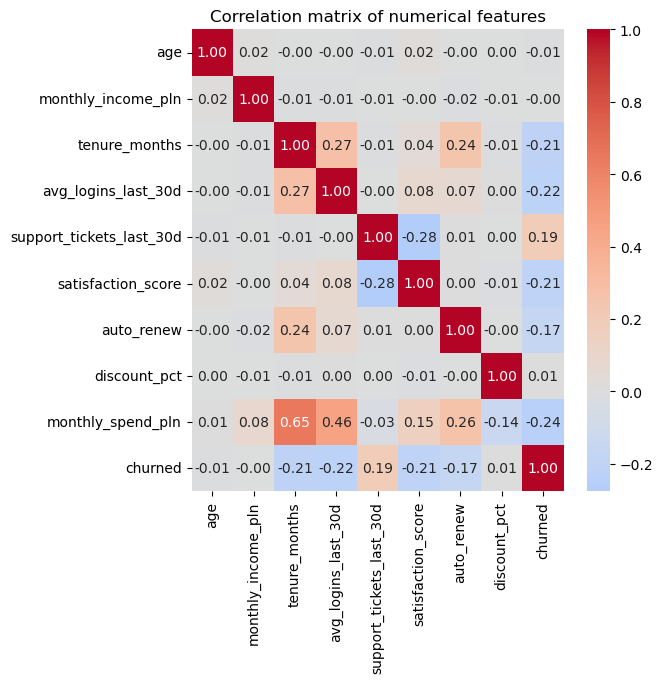

In [6]:
plt.figure(figsize=(6, 6))
sns.heatmap(data.select_dtypes("number").corr().drop(columns=["monthly_spend_pln"]), cmap="coolwarm", center=0, annot=True, fmt=".2f") 
plt.title('Correlation matrix of numerical features')
plt.show()

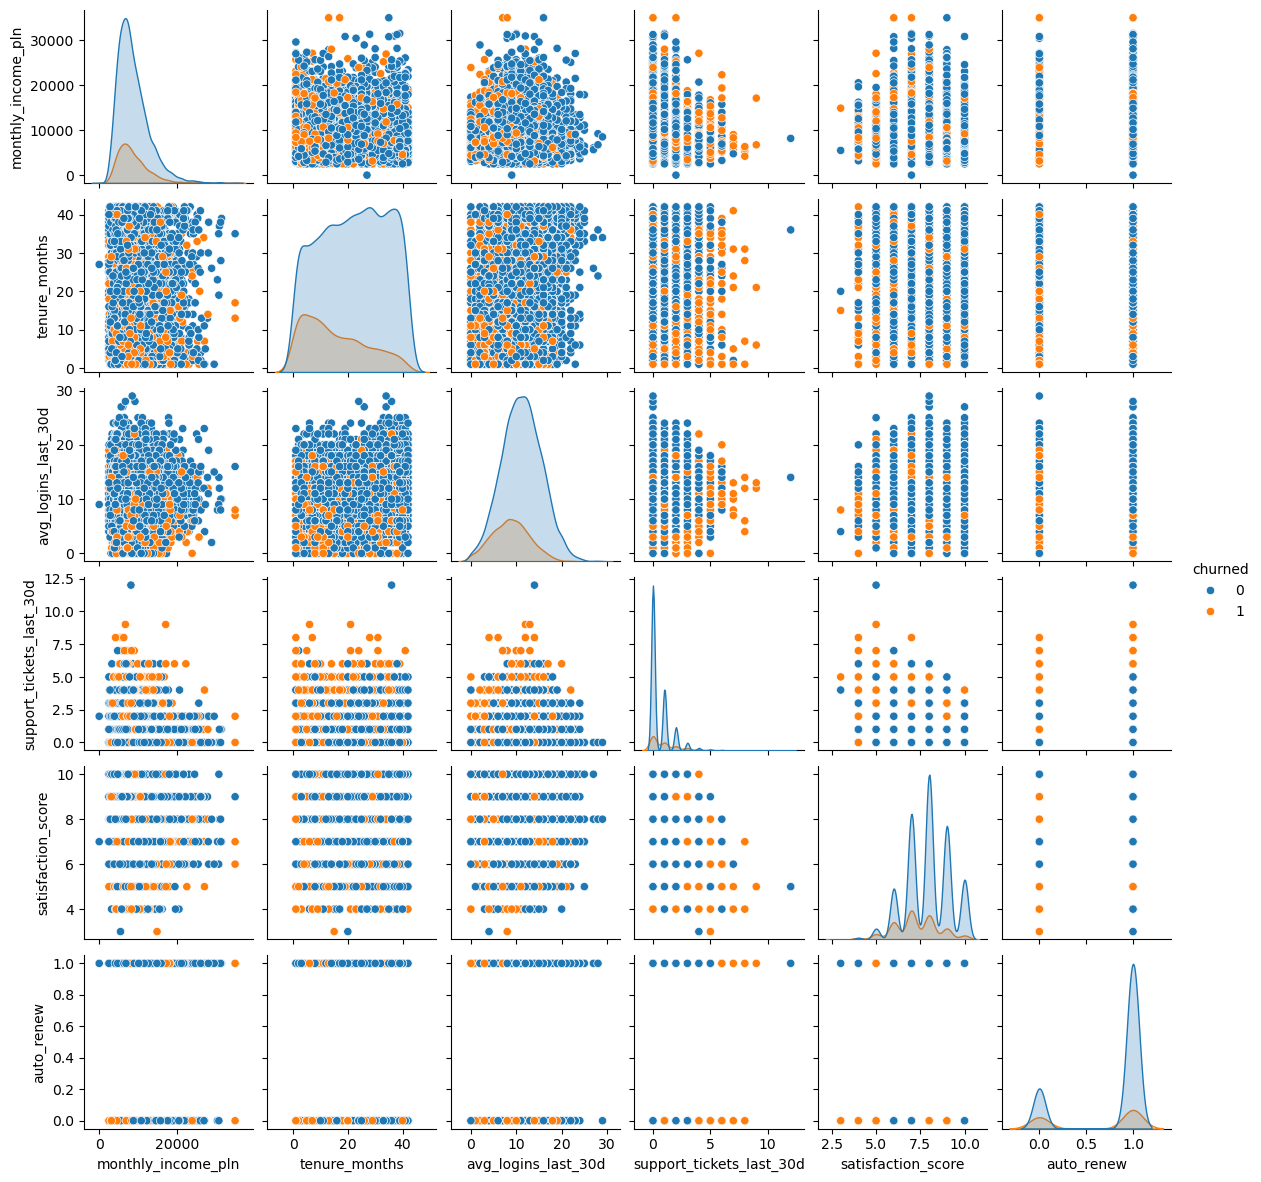

In [7]:
cols = [
    'monthly_income_pln',
    'tenure_months',
    'avg_logins_last_30d',
    'support_tickets_last_30d',
    'satisfaction_score',
    'auto_renew',
    'churned'
]

sns.pairplot(data[cols], hue='churned', height=2)
plt.show()

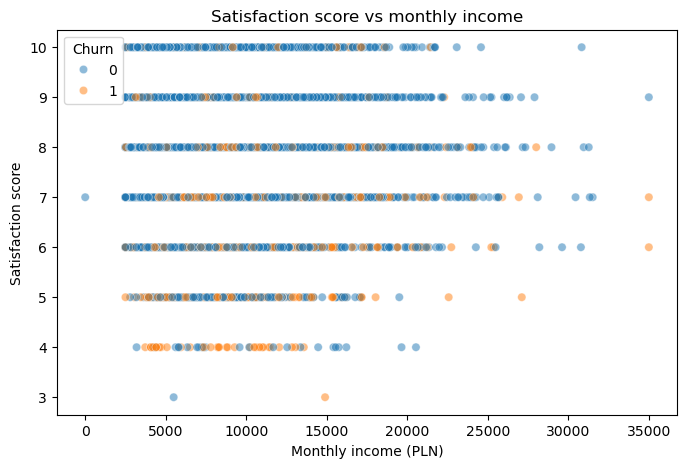

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="monthly_income_pln",
    y="satisfaction_score",
    hue="churned",
    alpha=0.5
)

plt.title("Satisfaction score vs monthly income")
plt.xlabel("Monthly income (PLN)")
plt.ylabel("Satisfaction score")
plt.legend(title="Churn")

plt.show()

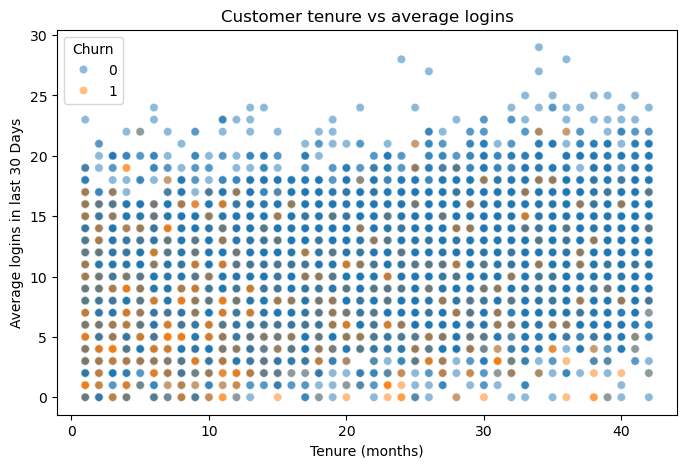

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="tenure_months",
    y="avg_logins_last_30d",
    hue="churned",
    alpha=0.5
)

plt.title("Customer tenure vs average logins")
plt.xlabel("Tenure (months)")
plt.ylabel("Average logins in last 30 Days")
plt.legend(title="Churn")

plt.show()

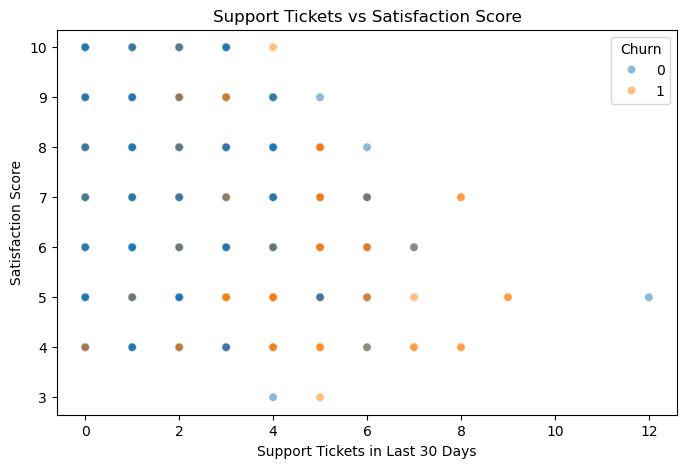

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="support_tickets_last_30d",
    y="satisfaction_score",
    hue="churned",
    alpha=0.5
)

plt.title("Support Tickets vs Satisfaction Score")
plt.xlabel("Support Tickets in Last 30 Days")
plt.ylabel("Satisfaction Score")
plt.legend(title="Churn")

plt.show()

# 6. Target definition

The target variable is `churned`, where:

- `0` represents a customer who did not churn,
- `1` represents a customer who churned.

The `monthly_spend_pln` variable was excluded from the feature set because it was used as the target in the regression project and is not required for the churn classification task.

A new feature, `satisfaction_per_tenure`, was created:
` satisfaction_per_tenure = satisfaction_score / (tenure_months + 1) `
This feature combines customer satisfaction with tenure and may help identify customers whose satisfaction is relatively low compared with the length of their relationship with the company.

The `customer_id` and `join_date` variables were removed during data cleaning because they are identifiers or date fields that were not directly used as predictive features in this project.

In [11]:
X = data.drop(columns=[
    "monthly_spend_pln",
    "churned"
])
y = data["churned"]

# 7. Train/test split

The dataset was divided into training and test sets using a standard train/test split.

The training set is used for model development, cross-validation, hyperparameter optimization and threshold optimization. The test set is kept separate and is used only for the final evaluation of the selected model. In that way it is possible to avoid data leackage.

Because the classes are unbalanced, `stratify=y` was used when splitting the data. This keeps the same percentage of churned and non-churned customers in both the training and test sets. The two tables below show that the proportions have been maintained.

In [12]:
class_dist_before = (
    y.value_counts()
     .rename_axis("Churned")
     .reset_index(name="Count")
)

class_dist_before["Percentage"] = (
    class_dist_before["Count"]
    / class_dist_before["Count"].sum()
    * 100
)

class_dist_before

,Churned,Count,Percentage
0,0,8074,80.74
1,1,1926,19.26


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [14]:
class_dist_after_y_train = (
    y_train.value_counts()
     .rename_axis("Churned")
     .reset_index(name="Count")
)

class_dist_after_y_train["Percentage"] = (
    class_dist_after_y_train["Count"]
    / class_dist_after_y_train["Count"].sum()
    * 100
).round(2)

class_dist_after_y_train

,Churned,Count,Percentage
0,0,6459,80.74
1,1,1541,19.26


In [15]:
class_dist_after_y_test = (
    y_test.value_counts()
     .rename_axis("Churned")
     .reset_index(name="Count")
)

class_dist_after_y_test["Percentage"] = (
    class_dist_after_y_test["Count"]
    / class_dist_after_y_test["Count"].sum()
    * 100
).round(2)

class_dist_after_y_test

,Churned,Count,Percentage
0,0,1615,80.75
1,1,385,19.25


# 8. Preprocessing pipeline

For numerical features, missing values are replaced with the median and the values are standardized.
For categorical features, missing values are replaced with the most frequent value. Then, categorical variables are converted into numerical values using one-hot encoding.

All preprocessing steps are placed inside a scikit-learn pipeline. This makes sure that the preprocessing is fitted only on the training data and to avoid data leackage.

In [16]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
numeric_selector = make_column_selector(dtype_include="number")
categorical_selector = make_column_selector(dtype_include="object")

preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_selector),
                                 ('cat', categorical_transformer, categorical_selector)])

In [17]:
pipelines = { 
    "Baseline (Dummy)": Pipeline([('preprocessor', preprocessor), ('classifier', DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression": Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression())]), 
    "Decision Tree": Pipeline([('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=42))]), 
    "Random Forest": Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))]), 
    "KNN": Pipeline([('preprocessor', preprocessor), ('classifier', KNeighborsClassifier())]), 
    "SVC": Pipeline([('preprocessor', preprocessor), ('classifier', SVC())]), 
    "XGB": Pipeline([('preprocessor', preprocessor), ('classifier', XGBClassifier())]),
    "Gradient Boosting": Pipeline([('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier())]),
    "LGBM": Pipeline([('preprocessor', preprocessor), ('classifier', LGBMClassifier())])
}

# 9. Stratified cross-validation

Stratified 5-fold cross-validation was used to evaluate and compare the classification models.

Because the target classes are imbalanced, `StratifiedKFold` was selected instead of standard `KFold`. Stratification helps maintain a similar proportion of churned and non-churned customers in each fold, making the evaluation more consistent.

Accuracy was not used as the main evaluation metric because it can be misleading when one class is more frequent than the other. Instead, the models were evaluated using:

- Precision
- Recall
- F1 score
- F2 score
- ROC-AUC

The F2 score was included because the project focuses on identifying customers who are likely to churn. Compared with F1, F2 gives more importance to Recall.

The initial cross-validation results show different trade-offs between Precision and Recall. Decision Tree achieved the highest Recall and F2 score, while XGBoost achieved a lower F2 score but a higher ROC-AUC. This shows that model ranking ability and threshold-based classification performance can lead to different conclusions.

Decision Tree, XGBoost, LightGBM and Logistic Regression were selected for hyperparameter optimization because they showed useful F2, Recall or ROC-AUC results during the initial comparison. Logistic Regression was also included because it achieved the highest ROC-AUC and therefore showed good ranking ability.

In [18]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": f2_scorer,
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in pipelines.items():
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV F2": scores["test_f2"].mean(),
        "CV F2std": scores["test_f2"].std(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

comparison_cv = (
    pd.DataFrame(cv_results)
    .sort_values("CV F2", ascending=False)
    .reset_index(drop=True)
)

comparison_cv

,Model,CV Precision,CV Recall,CV F1,CV F2,CV F2std,CV ROC-AUC
0,Decision Tree,0.285335,0.306269,0.295196,0.301679,0.020479,0.561556
1,XGB,0.462842,0.227113,0.304110,0.252655,0.019626,0.704844
2,LGBM,0.528342,0.208286,0.297945,0.236736,0.025924,0.735587
3,Logistic Regression,0.624475,0.203755,0.306846,0.235369,0.033191,0.763768
4,KNN,0.448200,0.206372,0.282357,0.231245,0.023972,0.670203
5,Gradient Boosting,0.590544,0.195314,0.292933,0.225323,0.021604,0.751176
6,Random Forest,0.608880,0.131722,0.216081,0.156081,0.014841,0.728392
7,SVC,0.625183,0.120710,0.202258,0.143918,0.013692,0.685217
8,Baseline (Dummy),0.000000,0.000000,0.000000,0.000000,0.000000,0.500000


# 10. Hyperparameter optimization with RandomizedSearchCV

The most promising models were selected for hyperparameter optimization:
- Decision Tree
- XGBoost
- LightGBM
- Logistic Regression

RandomizedSearchCV was used to test different combinations of hyperparameters using stratified cross-validation.

The F2 score was used as the optimization metric because the main objective of the project is to identify as many churned customers as possible. This metric gives greater importance to Recall while still considering Precision.

After hyperparameter optimization, Logistic Regression achieved the highest cross-validation F2 score of 0.58. Decision Tree achieved the second-best result, while the optimized XGBoost and LightGBM models produced lower F2 scores. Based on these results, Logistic Regression and Decision Tree were selected as the leading candidates for further threshold optimization. Although XGBoost and LightGBM achieved relatively strong ROC-AUC values during the initial comparison, their optimized F2 scores were substantially lower. This indicates that good ranking performance did not translate into effective classification under the F2 objective.

In [19]:
optimization_pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "XGB": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]),

    "LGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(
            random_state=42,
            verbosity=-1
        ))
    ]),
        
     "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
        ))
    ])
}

In [20]:
param_distributions = {

    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["liblinear", "lbfgs"],
        "classifier__class_weight": [None, "balanced"]
    },

    "XGB": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__max_depth": [3, 4, 5, 6, 8],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0]
    },

    "LGBM": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__max_depth": [-1, 3, 5, 7, 10],
        "classifier__num_leaves": [15, 31, 50, 75],
        "classifier__min_child_samples": [10, 20, 30, 50],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0]
    },
    
    "Decision Tree": {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"]
},
}

In [21]:
best_models = {}
optimization_results = []

for name in optimization_pipelines:

    print(f"Optimizing {name}...")

    random_search = RandomizedSearchCV(
        estimator=optimization_pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=20,
        scoring=f2_scorer,
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )

    random_search.fit(X_train, y_train)

    best_models[name] = random_search.best_estimator_

    best_idx = random_search.best_index_

    optimization_results.append({
        "Model": name,
        "Best CV F2": random_search.best_score_,
        "CV F2 Std": random_search.cv_results_["std_test_score"][best_idx],
    })

optimization_results_df = (
    pd.DataFrame(optimization_results)
    .sort_values("Best CV F2", ascending=False)
    .reset_index(drop=True)
)

optimization_results_df


Optimizing Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Optimizing XGB...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Optimizing LGBM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

Optimizing Decision Tree...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


,Model,Best CV F2,CV F2 Std
0,Logistic Regression,0.578062,0.019428
1,Decision Tree,0.538629,0.011236
2,XGB,0.273786,0.018400
3,LGBM,0.265442,0.027353


# 11. Threshold selection 

The optimized threshold improves the model's ability to identify churned customers.

For Logistic Regression, the selected threshold is 0.32. This threshold is lower than the default value of 0.50, so more customers are classified as likely to churn. This increases Recall, which is consistent with the project objective.

The standard deviation of CV F2 is included to show how stable the result is across the five folds. Std should be considered together with the mean F2 score rather than as a separate performance metric.

In [22]:
threshold_results = []
thresholds = np.arange(0.10, 0.91, 0.01)
models_threshold = ["Logistic Regression", "Decision Tree"]


def make_threshold_scorer(threshold):
    def threshold_f2(estimator, X_val, y_val):
        y_proba = estimator.predict_proba(X_val)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        return fbeta_score(
            y_val,
            y_pred,
            beta=2,
            zero_division=0
        )
    return threshold_f2


for name in models_threshold:
    model = best_models[name]

    y_proba_oof = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    f2_scores = [
        fbeta_score(
            y_train,
            (y_proba_oof >= t).astype(int),
            beta=2,
            zero_division=0
        )
        for t in thresholds
    ]

    best_idx = np.argmax(f2_scores)
    best_threshold_for_model = thresholds[best_idx]

    fold_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=make_threshold_scorer(best_threshold_for_model),
        n_jobs=-1
    )["test_score"]

    threshold_results.append({
        "Model": name,
        "Best Threshold": best_threshold_for_model,
        "Optimized CV F2": f2_scores[best_idx],
        "CV F2 Mean": fold_scores.mean(),
        "CV F2 Std": fold_scores.std(ddof=1),
    })

threshold_results_df = (
    pd.DataFrame(threshold_results)
    .sort_values("Optimized CV F2", ascending=False)
    .reset_index(drop=True)
)

threshold_results_df


,Model,Best Threshold,Optimized CV F2,CV F2 Mean,CV F2 Std
0,Logistic Regression,0.32,0.606195,0.606180,0.006649
1,Decision Tree,0.35,0.580168,0.580106,0.012208


# 12. Final model evaluation

The final Logistic Regression model was trained on the full training set using the optimized hyperparameters.
The optimized classification threshold of 0.32 was then applied to predicted probabilities from the previously unseen test set.

In [23]:
best_model_name = threshold_results_df.iloc[0]["Model"]
best_threshold = threshold_results_df.iloc[0]["Best Threshold"]
final_model = best_models[best_model_name]

final_model.fit(X_train, y_train)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_proba >= best_threshold).astype(int)

os.makedirs("../models", exist_ok=True)
joblib.dump(
    {"model": final_model, "threshold": best_threshold},
    "../models/classification_model.pkl",
)

['../models/classification_model.pkl']

In [24]:
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
f2 = fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"=== FINAL RESULTS FOR {best_model_name.upper()} ===")
print(f"Best Decision Threshold: {best_threshold:.2f}")
print("-" * 40)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"F2-Score  : {f2:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("=" * 40)


=== FINAL RESULTS FOR LOGISTIC REGRESSION ===
Best Decision Threshold: 0.32
----------------------------------------
Precision : 0.2601
Recall    : 0.8545
F1-Score  : 0.3988
F2-Score  : 0.5865
ROC-AUC   : 0.7506


## 12.1 Default vs optimized classification threshold


In [25]:
y_test_pred_default = (
    y_test_proba >= 0.5
).astype(int)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "F2"
    ],
    
    "Default Threshold (0.50)": [
        precision_score(y_test, y_test_pred_default),
        recall_score(y_test, y_test_pred_default),
        f1_score(y_test, y_test_pred_default),
        fbeta_score(y_test, y_test_pred_default, beta=2)
    ],
    
    f"Optimized Threshold ({best_threshold:.2f})": [
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        fbeta_score(
            y_test,
            y_test_pred,
            beta=2,
            zero_division=0
        )
    ]
})

threshold_comparison

,Metric,Default Threshold (0.50),Optimized Threshold (0.32)
0,Precision,0.356354,0.260079
1,Recall,0.670130,0.854545
2,F1,0.465284,0.398788
3,F2,0.569788,0.586453


# 13. Final model diagnostics

The diagnostics include the confusion matrix, the Precision-Recall curve, the ROC curve, and the distribution of predicted churn probabilities. Together, these results show how the selected threshold affects the final classification decisions.

## 13.1 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for both classes.

- **True Negative (TN):** a non-churned customer correctly classified as non-churned.
- **False Positive (FP):** a non-churned customer classified as likely to churn.
- **False Negative (FN):** a churned customer that the model failed to identify.
- **True Positive (TP):** a churned customer correctly identified by the model.

Because the project gives more importance to Recall, False Negatives are especially important. The optimized threshold reduces the number of False Negatives compared with the default threshold, but it also creates more False Positives.


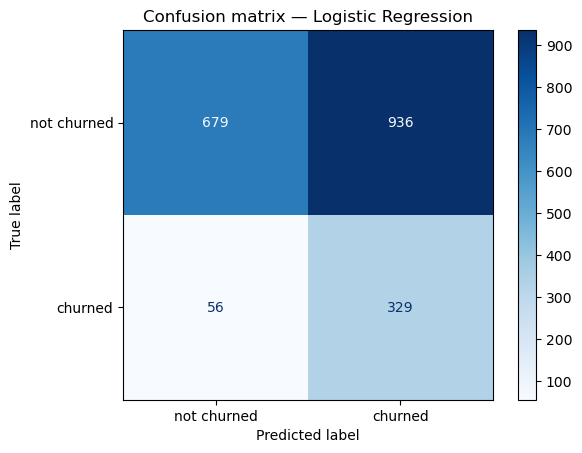

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap=plt.cm.Blues,
    display_labels=[
        "not churned",
        "churned"
    ]
)
plt.title(
    f"Confusion matrix — {best_model_name}"
)
plt.show()

## 13.2 Precision - recall curve

The Precision-Recall curve shows the relationship between Precision and Recall at different classification thresholds.

This curve is especially useful for an imbalanced classification problem because it focuses on the positive class. In this project, the positive class represents customers who churned.

The selected threshold of 0.32 is used for the final classification, but the curve shows the wider trade-off between Precision and Recall. Moving the threshold lower usually increases Recall and decreases Precision.


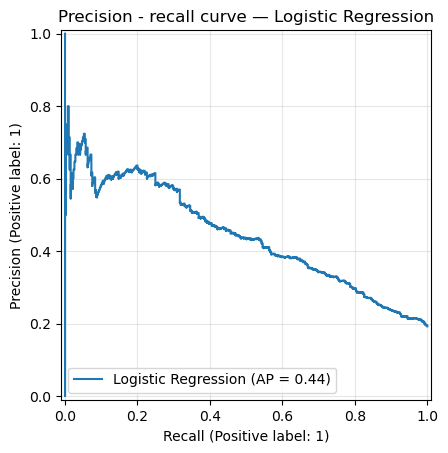

In [27]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=best_model_name
)
plt.title(
    f"Precision - recall curve — {best_model_name}"
)
plt.grid(alpha=0.3)
plt.show()

In [28]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

pd.DataFrame(
    {"value": [tn, fp, fn, tp]},
    index=["True negative", "False positive", "False negative", "True positive"],
)

,value
True negative,679
False positive,936
False negative,56
True positive,329


## 13.3 ROC curve

The ROC curve shows the relationship between the True Positive Rate and the False Positive Rate across different classification thresholds.

The ROC-AUC value summarizes the model's ability to separate churned and non-churned customers based on predicted probabilities. It evaluates ranking ability rather than the final classification threshold.

Therefore, ROC-AUC and F2 answer different questions. ROC-AUC describes discrimination across thresholds, while F2 evaluates the chosen classification decisions with more weight on Recall.


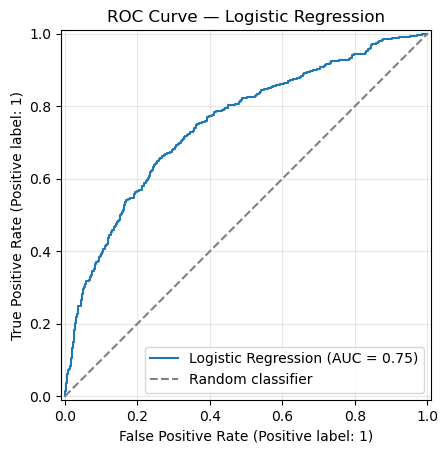

In [29]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=best_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.title(
    f"ROC Curve — {best_model_name}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 13.4 Distribution of predicted churn

The histogram shows the predicted probability of churn for churned and non-churned customers. The vertical line represents the optimized threshold. Customers with a predicted probability at or above this value are classified as likely to churn. The amount of overlap between the two distributions shows that the classes cannot be separated perfectly. Some customers therefore remain difficult to classify correctly.


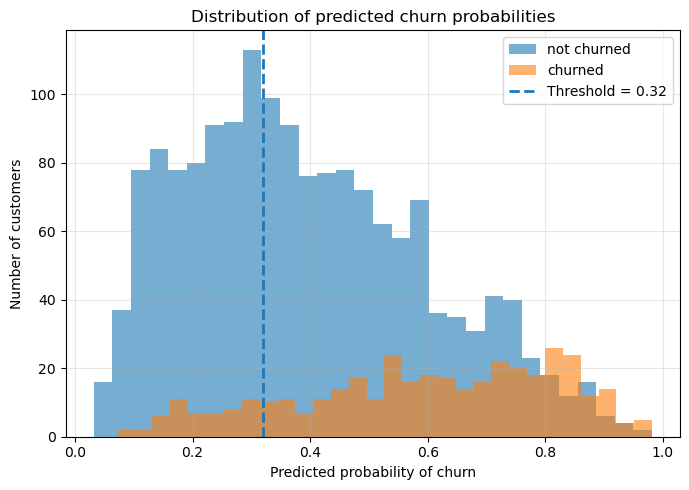

In [30]:
plt.figure(figsize=(7, 5))

plt.hist(
    y_test_proba[y_test == 0],
    bins=30,
    alpha=0.6,
    label="not churned"
)

plt.hist(
    y_test_proba[y_test == 1],
    bins=30,
    alpha=0.6,
    label="churned"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted probability of churn")
plt.ylabel("Number of customers")
plt.title("Distribution of predicted churn probabilities")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 14. Error analysis

Error analysis helps explain where the final model makes mistakes.

The analysis focuses on False Negatives and True Positives because both groups contain customers who actually churned. Comparing these groups can show which customer characteristics are associated with cases that the model identifies correctly and cases that it misses.

The analysis below compares tenure, satisfaction, login activity, support tickets and monthly income. These differences are descriptive and should not be interpreted as causal effects.


In [31]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_test_pred
error_analysis["Predicted Probability"] = y_test_proba


def classify_prediction(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "True Positive"
    elif row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"


error_analysis["Prediction Type"] = error_analysis.apply(
    classify_prediction,
    axis=1
)

In [32]:
features_to_compare = [
    "tenure_months",
    "satisfaction_score",
    "avg_logins_last_30d",
    "support_tickets_last_30d",
    "monthly_income_pln",
]

fn_tp_comparison = (
    error_analysis[
        error_analysis["Prediction Type"].isin(
            ["False Negative", "True Positive"]
        )
    ]
    .groupby("Prediction Type")[features_to_compare]
    .mean()
)

fn_tp_comparison

,tenure_months,satisfaction_score,avg_logins_last_30d,support_tickets_last_30d,monthly_income_pln
Prediction Type,,,,,
False Negative,26.696429,8.517857,12.857143,0.25000,8752.061698
True Positive,14.401216,7.142415,8.057751,1.18541,8668.850124


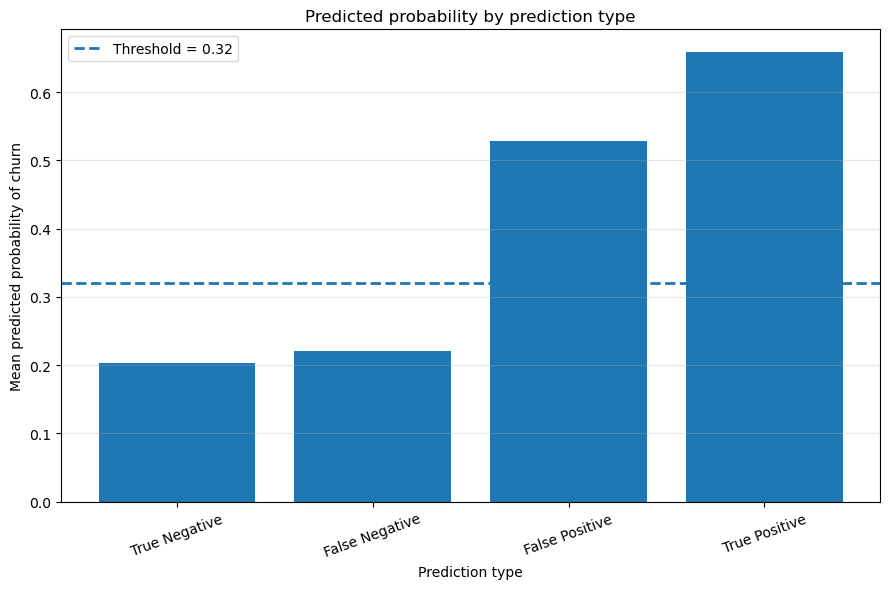

In [33]:
probability_summary = (
    error_analysis
    .groupby("Prediction Type")["Predicted Probability"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.bar(
    probability_summary.index,
    probability_summary.values
)

plt.axhline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Prediction type")
plt.ylabel("Mean predicted probability of churn")
plt.title("Predicted probability by prediction type")

plt.xticks(rotation=20)
plt.legend()

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 15. Feature importance

For the final Logistic Regression model, feature importance is examined using the model coefficients.

A positive coefficient increases the predicted log-odds of churn, while a negative coefficient decreases them, assuming the other features remain constant. Because numerical features are standardized and categorical variables are one-hot encoded in the pipeline, the coefficients can be compared more meaningfully than raw coefficients from an unscaled model.

The chart shows the 10 features with the largest absolute coefficients. The sign of each coefficient indicates the direction of its relationship with the model's prediction. These coefficients describe model behavior and should not be interpreted as proof of causation.


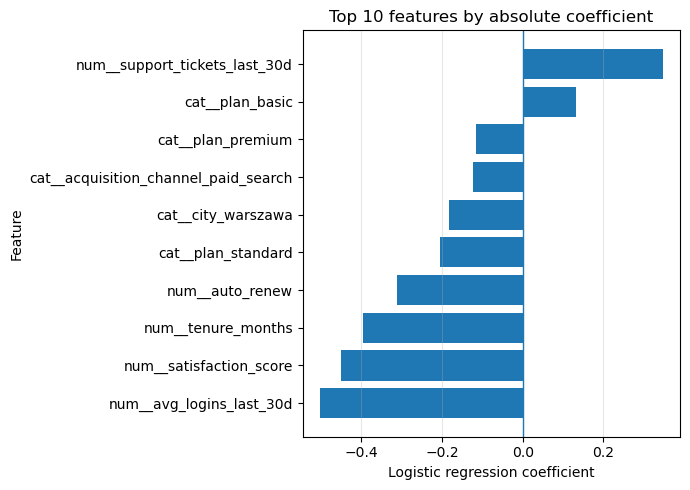

In [34]:
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
model_coef = final_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model_coef,
    "Absolute coefficient": np.abs(model_coef)
}).sort_values(
    "Absolute coefficient",
    ascending=False
).reset_index(drop=True)

top_n = 10

top_features = (
    coef_df
    .head(top_n)
    .sort_values("Coefficient")
)

plt.figure(figsize=(7, 5))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic regression coefficient")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features by absolute coefficient")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 16. Final conclusions

The final model is Logistic Regression with an optimized classification threshold of 0.32.
The main results on the previously unseen test set are:

- **Precision:** 0.260
- **Recall:** 0.855
- **F1 score:** 0.399
- **F2 score:** 0.586
- **ROC-AUC:** 0.751

The optimized threshold increases Recall from 0.670 at the default threshold of 0.50 to 0.855. At the same time, Precision decreases from 0.356 to 0.260. This trade-off is expected because the project places greater importance on identifying churned customers.

The final confusion matrix contains 329 True Positives and 56 False Negatives. This means that the model identifies most churned customers in the test set, but it also produces a relatively large number of False Positives.

Overall, the results show that threshold selection has a meaningful effect on the final classification behavior. The model should therefore be evaluated using the business objective and the cost of different types of errors, rather than using accuracy alone.
